In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('diabetes.csv')

print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (768, 9)

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Basic Statistics ===')
df.describe()

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== Basic Statistics ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
# 0 values medically impossible hain in columns mein
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 0 ko NaN se replace karo
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# NaN ko median se fill karo
df[cols_with_zeros] = df[cols_with_zeros].fillna(df[cols_with_zeros].median())

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Cleaning complete!')
print('Shape after cleaning:', df.shape)
df.head()

Cleaning complete!
Shape after cleaning: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


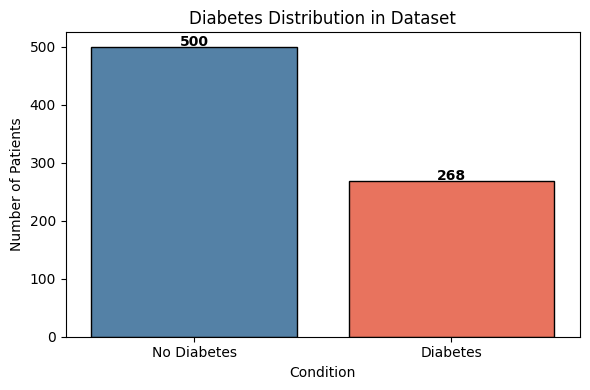

In [5]:
counts = df['Outcome'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values,
            palette=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.title('Diabetes Distribution in Dataset')
plt.xlabel('Condition')
plt.ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

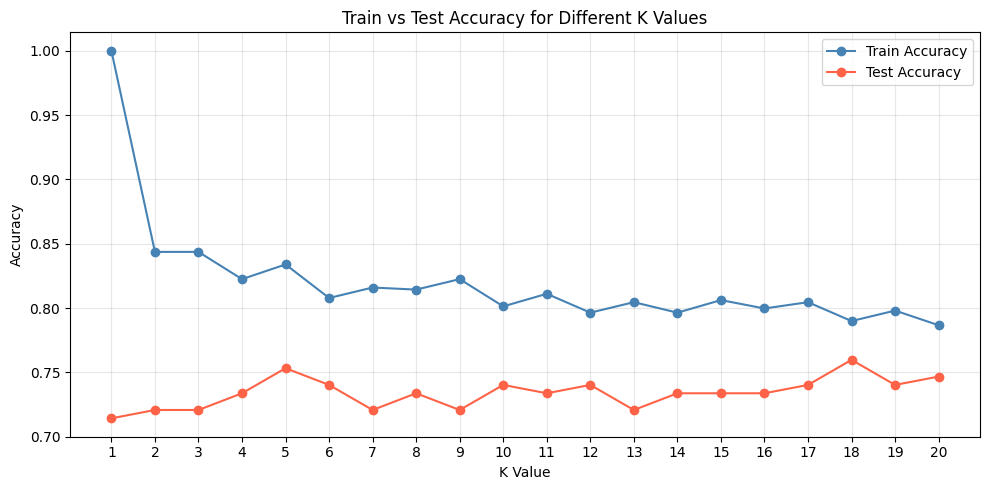

Best K value: 18
Best Test Accuracy: 75.97%


In [6]:
# K=1 se K=20 tak accuracy check karo
k_values = range(1, 21)
train_scores = []
test_scores  = []

X_temp = df.drop(columns=['Outcome'])
y_temp = df['Outcome']
scaler_temp = StandardScaler()
X_scaled_temp = scaler_temp.fit_transform(X_temp)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_tr, y_tr)
    train_scores.append(knn_temp.score(X_tr, y_tr))
    test_scores.append(knn_temp.score(X_te, y_te))

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(k_values, test_scores,  'o-', label='Test Accuracy',  color='tomato')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy for Different K Values')
plt.legend()
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(test_scores)]
print(f'Best K value: {best_k}')
print(f'Best Test Accuracy: {max(test_scores)*100:.2f}%')

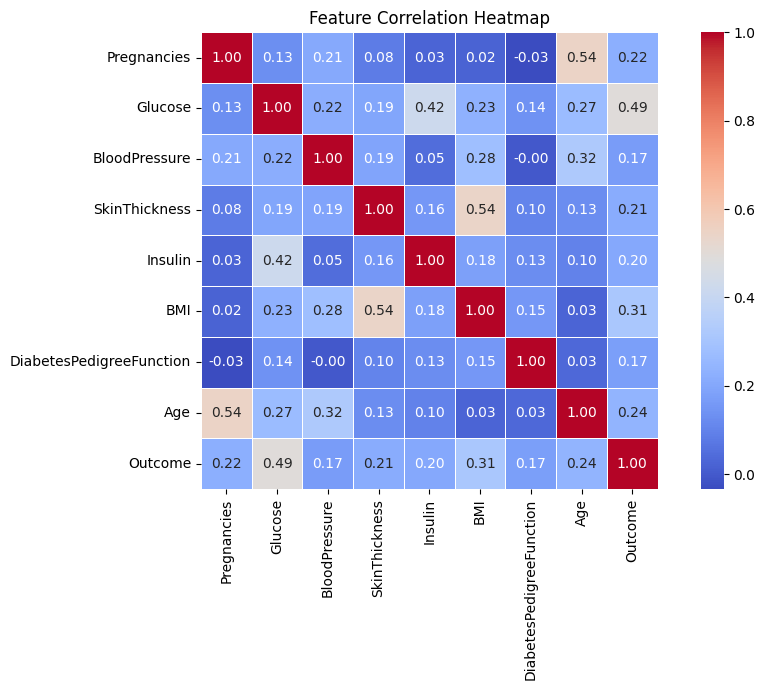

In [7]:
plt.figure(figsize=(10, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()